In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Clean_Diabetes.csv to Clean_Diabetes.csv


In [5]:
df=pd.read_csv("/content/Clean_Diabetes.csv")

In [6]:
df

,DIABETE4,_RFHYPE6,_RFCHOL3,_CHOLCH3,_BMI5,SMOKE100,CVDSTRK3,_MICHD,EXERANY2,PRIMINS1,...,DIFFWALK,_SEX,_AGEG5YR,_EDUCAG,_INCOMG1,BMI,BMI_Category,HealthScore,LifestyleScore,RiskScore
0,1.0,2,1.0,1,3047.0,2.0,2.0,2.0,2.0,3.0,...,1.0,2,13,3,9,30.47,3,178.0,4.0,37.47
1,3.0,2,2.0,1,2856.0,2.0,2.0,2.0,1.0,3.0,...,2.0,2,13,3,9,28.56,2,178.0,3.0,36.56
2,3.0,2,2.0,1,2231.0,1.0,2.0,2.0,1.0,3.0,...,1.0,2,13,2,1,22.31,1,12.0,2.0,30.31
3,3.0,1,1.0,1,2744.0,2.0,2.0,2.0,1.0,3.0,...,1.0,2,12,3,9,27.44,2,92.0,3.0,33.44
4,1.0,2,1.0,1,2585.0,2.0,2.0,2.0,1.0,3.0,...,1.0,2,12,3,5,25.85,2,180.0,3.0,32.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
415112,3.0,2,2.0,1,2921.0,2.0,7.0,2.0,1.0,77.0,...,2.0,1,10,3,3,29.21,2,45.0,3.0,42.21
415113,3.0,1,1.0,1,2496.0,2.0,2.0,2.0,2.0,1.0,...,2.0,2,3,4,4,24.96,1,178.0,4.0,30.96
415114,3.0,1,2.0,1,3438.0,2.0,2.0,2.0,1.0,1.0,...,2.0,2,7,4,6,34.38,3,100.0,3.0,41.38
415115,1.0,2,2.0,1,2386.0,2.0,2.0,2.0,1.0,3.0,...,2.0,2,10,4,2,23.86,1,179.0,3.0,31.86


In [8]:
!pip install catboost
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)
from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.5 MB/s eta 0:00:00


In [9]:
from imblearn.over_sampling import SMOTE

In [10]:
X = df.drop("DIABETE4", axis=1)
y = df["DIABETE4"]
print(X.shape)
print(y.shape)

(415117, 23)
(415117,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=42,stratify=y)

In [13]:
from sklearn.impute import SimpleImputer

smote = SMOTE(random_state=42)

# Impute missing values in X_train before applying SMOTE
imputer = SimpleImputer(strategy='mean') # You can choose 'median' or 'most_frequent' as well
X_train_imputed = imputer.fit_transform(X_train)

X_train_smote, y_train_smote = smote.fit_resample(X_train_imputed, y_train)
print("Before SMOTE")
print(y_train.value_counts())
print()
print("After SMOTE")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE
DIABETE4
3.0    281747
1.0     47747
2.0      2599
Name: count, dtype: int64

After SMOTE
DIABETE4
3.0    281747
1.0    281747
2.0    281747
Name: count, dtype: int64


In [16]:

model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    loss_function="MultiClass",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=100
)

model.fit(X_train_smote,y_train_smote)

0:	learn: 0.7581057	total: 2.53s	remaining: 21m 1s
100:	learn: 0.8831493	total: 2m 55s	remaining: 11m 31s
200:	learn: 0.8960640	total: 5m 38s	remaining: 8m 24s
300:	learn: 0.9032146	total: 8m 14s	remaining: 5m 26s
400:	learn: 0.9090792	total: 10m 48s	remaining: 2m 40s
499:	learn: 0.9132567	total: 13m 57s	remaining: 0us


CatBoostClassifier(depth=8, eval_metric='Accuracy', iterations=500, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=100)

In [17]:
y_pred = model.predict(X_test)
y_pred = y_pred.astype(int)

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", round(accuracy*100,2),"%")

Accuracy : 85.35 %


In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       0.55      0.18      0.27     11937
         2.0       0.00      0.00      0.00       650
         3.0       0.87      0.98      0.92     70437

    accuracy                           0.85     83024
   macro avg       0.47      0.38      0.40     83024
weighted avg       0.82      0.85      0.82     83024



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

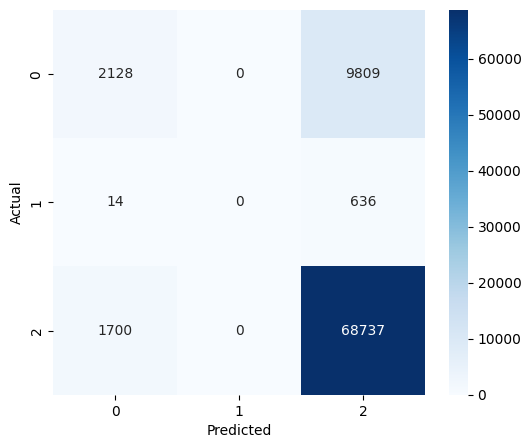

In [22]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
importance = pd.DataFrame({"Feature": X.columns,"Importance": model.feature_importances_})
importance = importance.sort_values("Importance",ascending=False)
importance.head(15)

,Feature,Importance
14,_SEX,15.067638
10,GENHLTH,9.753915
16,_EDUCAG,9.042936
0,_RFHYPE6,8.482729
15,_AGEG5YR,8.379186
17,_INCOMG1,8.009849
1,_RFCHOL3,6.740614
8,PRIMINS1,4.963574
7,EXERANY2,4.383161
4,SMOKE100,3.580633


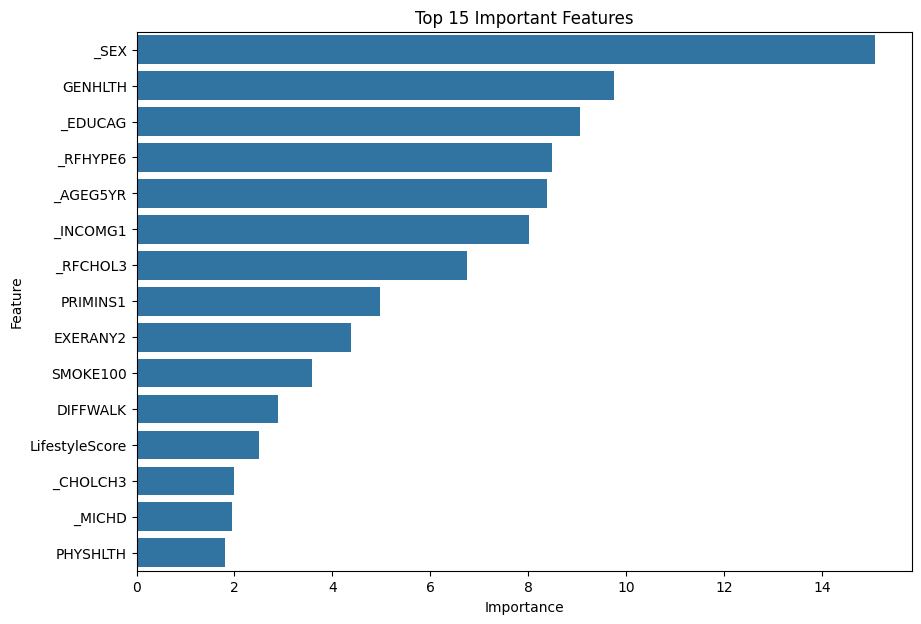

In [24]:
plt.figure(figsize=(10,7))
sns.barplot(data=importance.head(15),x="Importance",y="Feature")
plt.title("Top 15 Important Features")
plt.show()

In [25]:
import joblib
joblib.dump(model, "CatBoost_Diabetes_Model.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [26]:
import joblib
loaded_model = joblib.load("CatBoost_Diabetes_Model.pkl")

In [27]:
sample = X_test.iloc[[0]]
prediction = loaded_model.predict(sample)
print("Predicted Class :", int(prediction[0][0]))

Predicted Class : 3


In [28]:
prediction = int(prediction[0][0])
if prediction == 1:
    print("🩺 Diabetes")
elif prediction == 2:
    print(" Prediabetes")
else:
    print(" No Diabetes")

 No Diabetes


In [29]:
probability = loaded_model.predict_proba(sample)
print(probability)

[[0.25709391 0.01382994 0.72907615]]


In [30]:
user_data = pd.DataFrame({

    "_RFHYPE6":[1],
    "_RFCHOL3":[1],
    "_CHOLCH3":[1],
    "_BMI5":[3200],
    "SMOKE100":[1],
    "CVDSTRK3":[2],
    "_MICHD":[2],
    "EXERANY2":[1],
    "PRIMINS1":[1],
    "MEDCOST1":[2],
    "GENHLTH":[3],
    "MENTHLTH":[5],
    "PHYSHLTH":[2],
    "DIFFWALK":[2],
    "_SEX":[1],
    "_AGEG5YR":[9],
    "_EDUCAG":[3],
    "_INCOMG1":[4],
    "BMI":[32.0],
    "BMI_Category":[3],
    "HealthScore":[10],
    "LifestyleScore":[2],
    "RiskScore":[38]

})

In [31]:
prediction = loaded_model.predict(user_data)
prediction = int(prediction[0][0])
if prediction == 1:
    print("🩺 Prediction : Diabetes")
elif prediction == 2:
    print(" Prediction : Prediabetes")
else:
    print(" Prediction : No Diabetes")

 Prediction : No Diabetes


In [32]:
prob = loaded_model.predict_proba(user_data)
confidence = prob.max() * 100
prediction = int(loaded_model.predict(user_data)[0][0])
if prediction == 1:
    disease = "Diabetes"
elif prediction == 2:
    disease = "Prediabetes"
else:
    disease = "No Diabetes"
print("="*40)
print("Health Risk Prediction")
print("="*40)
print(f"Prediction : {disease}")
print(f"Confidence : {confidence:.2f}%")
print("="*40)

Health Risk Prediction
Prediction : No Diabetes
Confidence : 84.46%


In [41]:
import pandas as pd
print("Enter Patient Details")
rfhype6 = int(input("High Blood Pressure (1=Yes, 2=No): "))
rfchol3 = int(input("High Cholesterol (1=Yes, 2=No): "))
cholch3 = int(input("Cholesterol Checked (1=Yes, 2=No): "))
bmi = float(input("BMI (Example: 27.5): "))
smoke100 = int(input("Smoked 100 Cigarettes in Lifetime (1=Yes, 2=No): "))
cvdstrk3 = int(input("Stroke (1=Yes, 2=No): "))
michd = int(input("Heart Disease (1=Yes, 2=No): "))
exerany2 = int(input("Physical Activity (1=Yes, 2=No): "))
primins1 = int(input("Health Insurance (1=Yes, 2=No): "))
medcost1 = int(input("Medical Cost Issue (1=Yes, 2=No): "))
genhlth = int(input("General Health (1-5): "))
menthlth = int(input("Poor Mental Health Days (0-30): "))
physhlth = int(input("Poor Physical Health Days (0-30): "))
diffwalk = int(input("Difficulty Walking (1=Yes, 2=No): "))
sex = int(input("Gender (1=Male, 2=Female): "))
age = int(input("Age Group (1-13): "))
educ = int(input("Education Level (1-4): "))
income = int(input("Income Group (1-6): "))

Enter Patient Details
High Blood Pressure (1=Yes, 2=No): 1
High Cholesterol (1=Yes, 2=No): 2
Cholesterol Checked (1=Yes, 2=No): 1
BMI (Example: 27.5): 1
Smoked 100 Cigarettes in Lifetime (1=Yes, 2=No): 2
Stroke (1=Yes, 2=No): 2
Heart Disease (1=Yes, 2=No): 2
Physical Activity (1=Yes, 2=No): 2
Health Insurance (1=Yes, 2=No): 3
Medical Cost Issue (1=Yes, 2=No): 2
General Health (1-5): 2
Poor Mental Health Days (0-30): 88
Poor Physical Health Days (0-30): 88
Difficulty Walking (1=Yes, 2=No): 1
Gender (1=Male, 2=Female): 2
Age Group (1-13): 13
Education Level (1-4): 3
Income Group (1-6): 9


In [42]:
bmi5 = bmi * 100
if bmi < 18.5:
    bmi_category = 0
elif bmi < 25:
    bmi_category = 1
elif bmi < 30:
    bmi_category = 2
else:
    bmi_category = 3
health_score = genhlth + menthlth + physhlth
lifestyle_score = smoke100 + exerany2
risk_score = rfhype6 + rfchol3 + cvdstrk3 + michd + bmi

In [43]:
user_data = pd.DataFrame({
    "_RFHYPE6":[rfhype6],
    "_RFCHOL3":[rfchol3],
    "_CHOLCH3":[cholch3],
    "_BMI5":[bmi5],
    "SMOKE100":[smoke100],
    "CVDSTRK3":[cvdstrk3],
    "_MICHD":[michd],
    "EXERANY2":[exerany2],
    "PRIMINS1":[primins1],
    "MEDCOST1":[medcost1],
    "GENHLTH":[genhlth],
    "MENTHLTH":[menthlth],
    "PHYSHLTH":[physhlth],
    "DIFFWALK":[diffwalk],
    "_SEX":[sex],
    "_AGEG5YR":[age],
    "_EDUCAG":[educ],
    "_INCOMG1":[income],
    "BMI":[bmi],
    "BMI_Category":[bmi_category],
    "HealthScore":[health_score],
    "LifestyleScore":[lifestyle_score],
    "RiskScore":[risk_score]

})

In [45]:
prediction = loaded_model.predict(user_data)
probability = loaded_model.predict_proba(user_data)
prediction = int(prediction[0][0])
if prediction == 1:
    result = "Diabetes"
elif prediction == 2:
    result = "Prediabetes"
else:
    result = "No Diabetes"
confidence = probability.max() * 100
print("\n Prediction Result ")
print("Prediction :", result)
print("Confidence :", round(confidence,2), "%")


 Prediction Result 
Prediction : No Diabetes
Confidence : 91.96 %
